In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages


In [3]:
path_output = 'simulation_output/'
simulation_name = os.listdir(path_output)

In [4]:
exec(open('./functions/05_indice_Calculation.py').read())

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: divide by zero encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass\lib\site-packages\ipykernel_launcher.py:46: RuntimeWarning: invalid value encountered in true_divide
C:\Users\ne

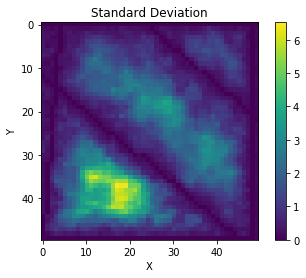

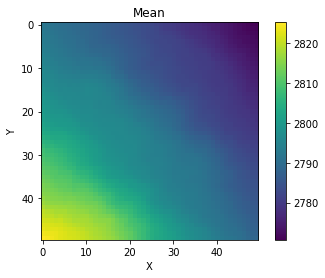

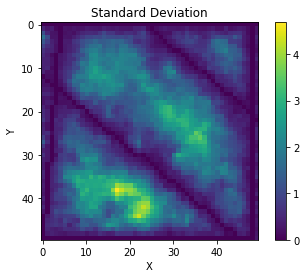

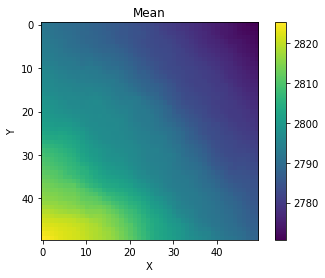

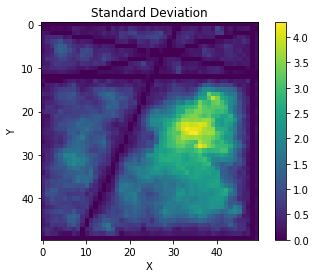

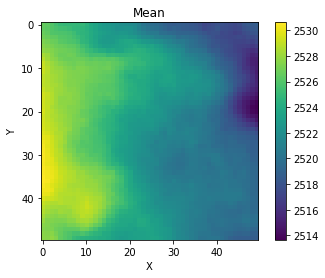

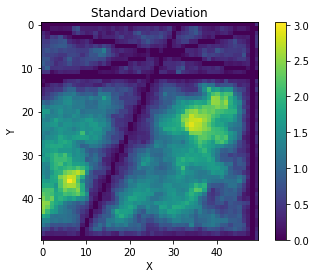

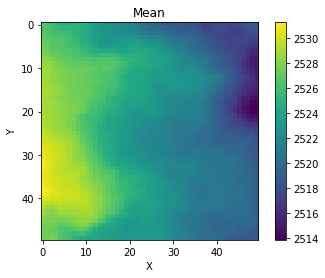

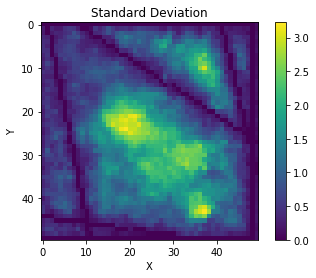

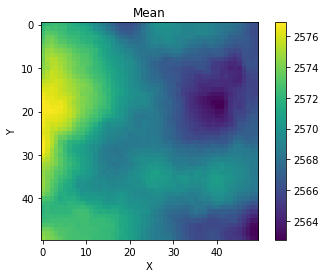

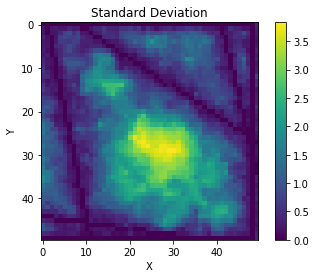

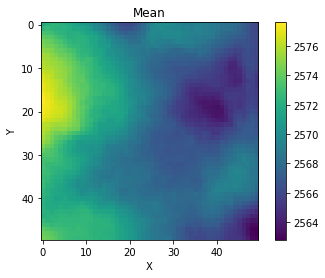

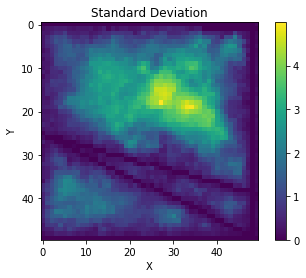

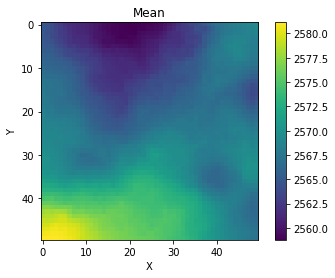

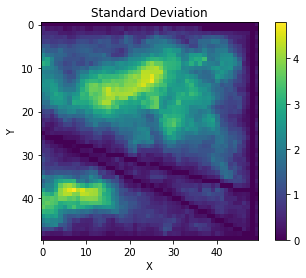

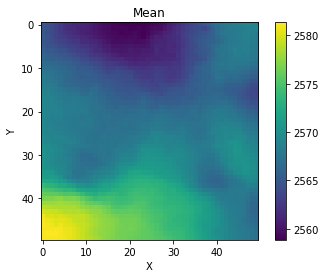

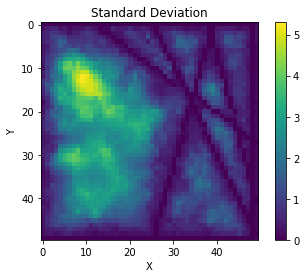

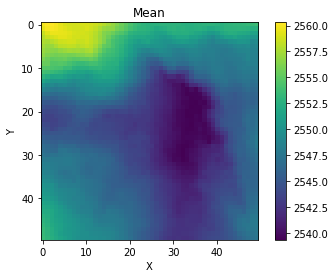

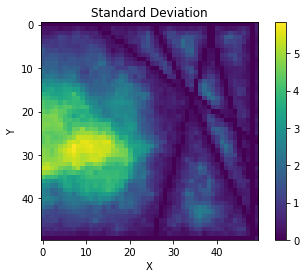

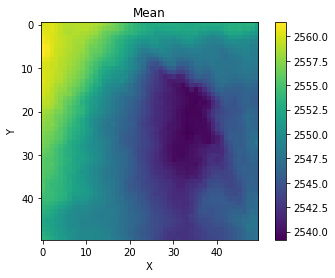

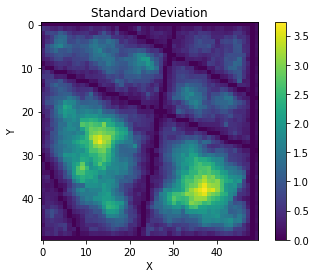

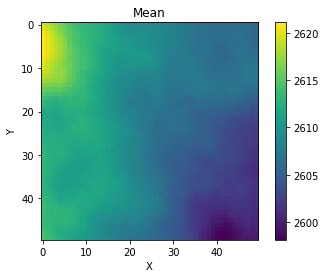

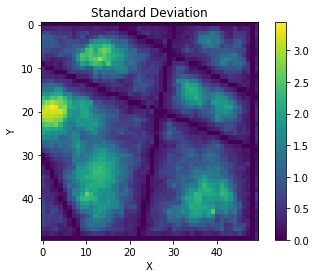

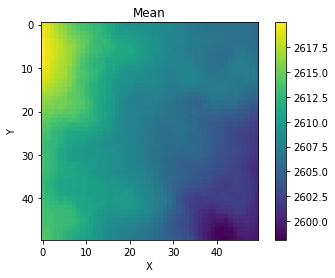

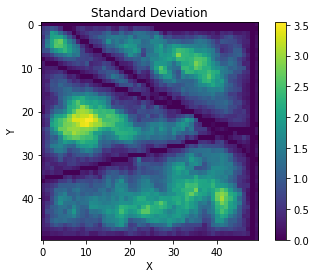

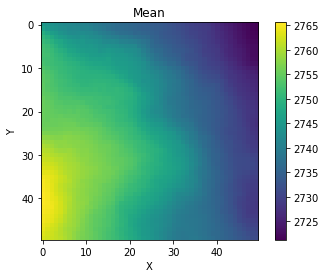

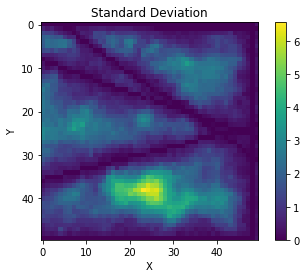

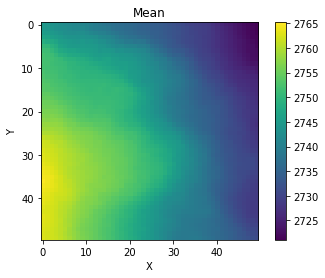

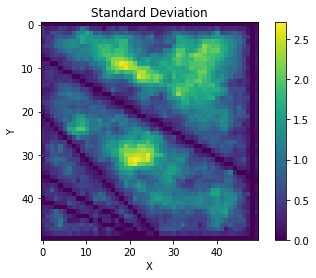

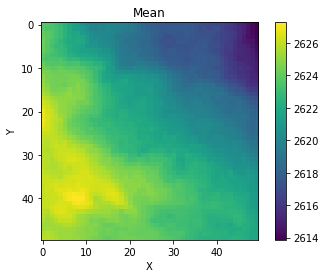

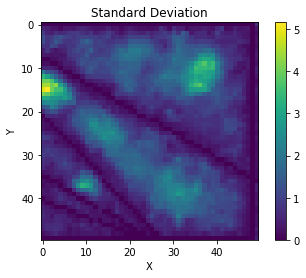

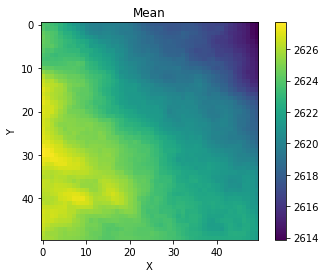

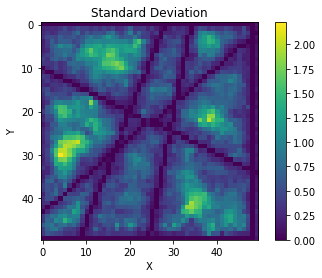

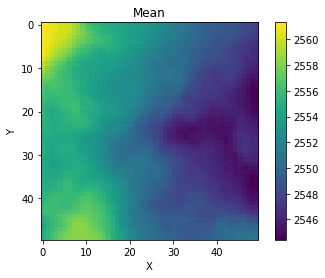

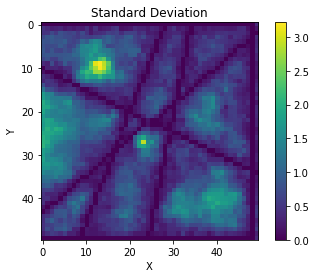

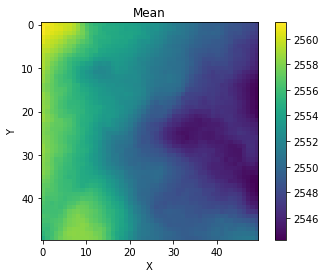

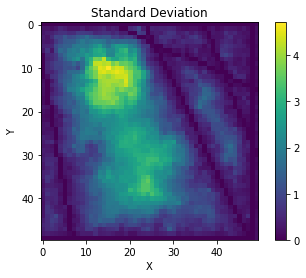

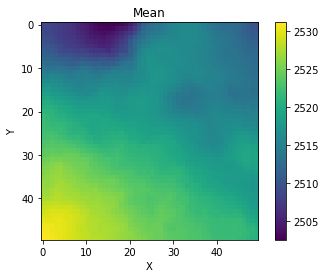

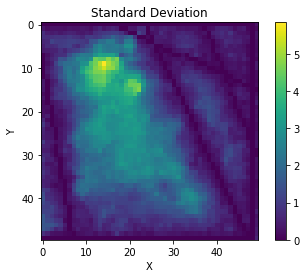

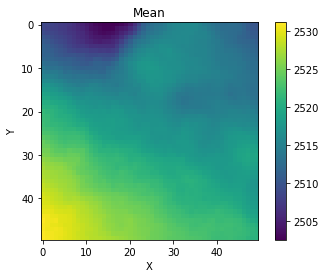

In [6]:
all_output = []
for name in simulation_name:
    pp = PdfPages(name+'.pdf')
    
    with open('simulation_output/'+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)
    
    for simus in simus_sets:
        pro = indice_calculation(real_alt,simus)
        all_output.append(pro)
        
        fig = plt.figure()
        plt.imshow(pro[4])
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Standard Deviation')
        plt.colorbar()
        pp.savefig(fig)
        
        fig = plt.figure()
        plt.imshow(pro[3])
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Mean')
        plt.colorbar()

        pp.savefig(fig)
        
    pp.close()
        

In [ ]:
real_alt.shape

Text(0.5, 0, 'Simulation number')

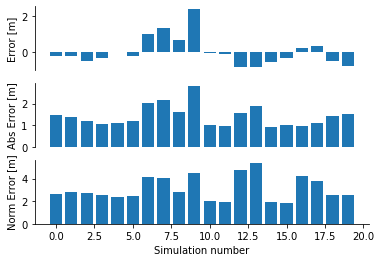

In [31]:
def simpleaxis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.tick_params(bottom=False)
    ax.tick_params(labelbottom=False)
    
    
pts_0 = [ide[0] for ide in all_output]
pts_1 = [ide[1] for ide in all_output]
pts_2 = [ide[2] for ide in all_output]

ax = plt.subplot(311)
plt.bar(range(len(pts_0)),pts_0)
simpleaxis(ax)
plt.ylabel('Error [m]')

ax2 = plt.subplot(312)
plt.bar(range(len(pts_0)),pts_1)
simpleaxis(ax2)
plt.ylabel('Abs Error [m]')

ax3 = plt.subplot(313)
plt.bar(range(len(pts_0)),pts_2)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.ylabel('Norm Error [m]')

plt.xlabel('Simulation number')


In [ ]:
plt.plot(pts_0,color='tan')
plt.plot(pts_1)
plt.plot(pts_2)
plt.legend(['error','abs_error','norm_error'])
plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')
#plt.plot(pts[2])
#plt.plot(pts[0])

In [ ]:
for ide in all_output:
    plt.imshow(ide[4])
    plt.show()